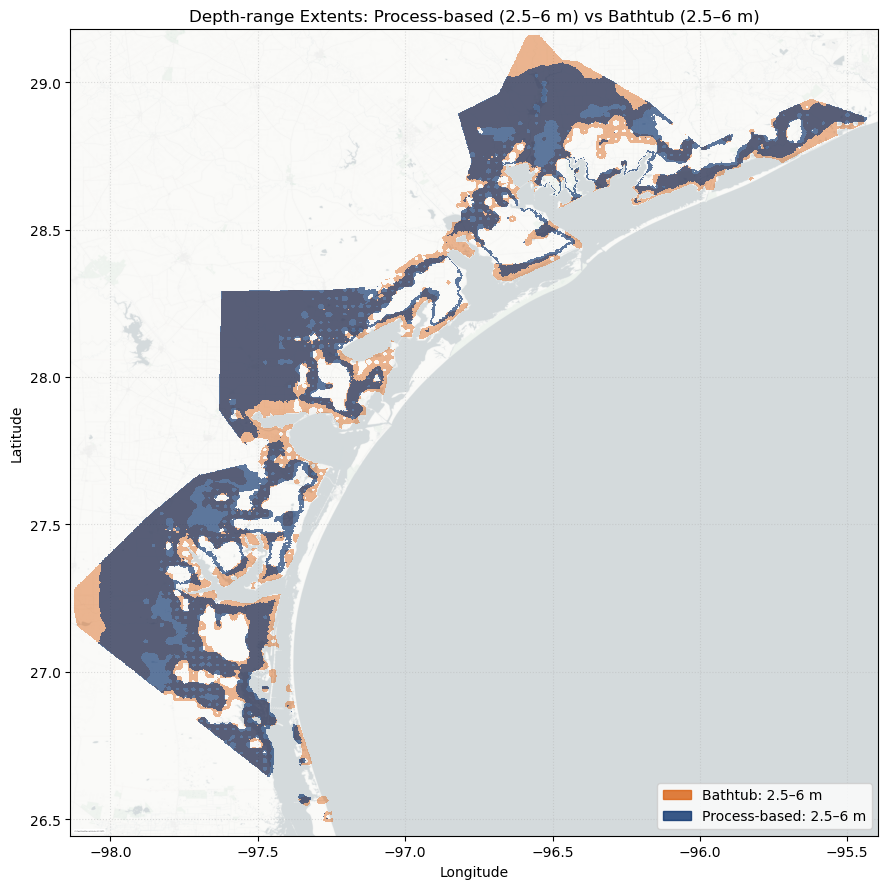

In [2]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import contextily as ctx
import math
import matplotlib.patches as mpatches

# ---------- USER INPUTS ----------
r_proc   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"      # process-based depth
r_bath   = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"       # bathtub depth

# Depth ranges (inclusive of min, exclusive of max for binning; ok for plotting)
PROC_RANGE = (2.5, 6.0)     # meters
BATH_RANGE = (2.5, 6.0)     # meters

# Plot grid (lat/lon) and target resolution
TARGET_CRS = "EPSG:4326"
TARGET_RES_DEG = 0.0005     # ~45–55 m in TX; increase if memory is an issue

# Basemap toggle
ADD_BASEMAP = True
MAIN_ZOOM   = 12
# ----------------------------------

def read_mask_in_range(path, vmin, vmax):
    """Return (0/1 mask where vmin<=depth<=vmax, profile dict)."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        valid = (~arr.mask) & np.isfinite(arr)
        m = np.zeros(arr.shape, dtype="uint8")
        m[valid & (arr >= vmin) & (arr <= vmax)] = 1
        prof = {"crs": src.crs, "transform": src.transform,
                "width": src.width, "height": src.height}
    return m, prof

def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res_deg):
    width  = int(math.ceil((right  - left) / res_deg))
    height = int(math.ceil((top    - bottom) / res_deg))
    transform = from_origin(left, top, res_deg, res_deg)
    return transform, width, height

def reproject_mask_uint8(src_mask, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask,
        destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform,      dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
    return dst

# --- Read both masks in their depth ranges ---
mask_proc, prof_proc = read_mask_in_range(r_proc, *PROC_RANGE)
mask_bath, prof_bath = read_mask_in_range(r_bath, *BATH_RANGE)

# --- Common grid covering both in EPSG:4326 ---
left, bottom, right, top = union_bounds_in_target([prof_proc, prof_bath], TARGET_CRS)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES_DEG)

# --- Reproject masks to the common grid ---
dst_proc = reproject_mask_uint8(mask_proc, prof_proc, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_bath = reproject_mask_uint8(mask_bath, prof_bath, dst_transform, TARGET_CRS, dst_w, dst_h)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 9))
extent = (left, right, bottom, top)

# Transparent colormaps
cmap_proc = ListedColormap([(0,0,0,0), (8/255, 48/255, 107/255, 0.65)])    # dark blue
cmap_bath = ListedColormap([(0,0,0,0), (217/255, 95/255, 14/255, 0.45)])   # orange

# Draw overlays (order so overlap is visible)
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bath, interpolation="nearest", zorder=3)
ax.imshow(dst_proc, extent=extent, origin="upper", cmap=cmap_proc, interpolation="nearest", zorder=4)

# Basemap
if ADD_BASEMAP:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                    zoom=MAIN_ZOOM, zorder=1, attribution_size=0)

# Labels/legend
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Depth-range Extents: Process-based (2.5–6 m) vs Bathtub (2.5–6 m)")

legend_patches = [
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.80), label="Bathtub: 2.5–6 m"),
    mpatches.Patch(color=(8/255, 48/255, 107/255, 0.80), label="Process-based: 2.5–6 m"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


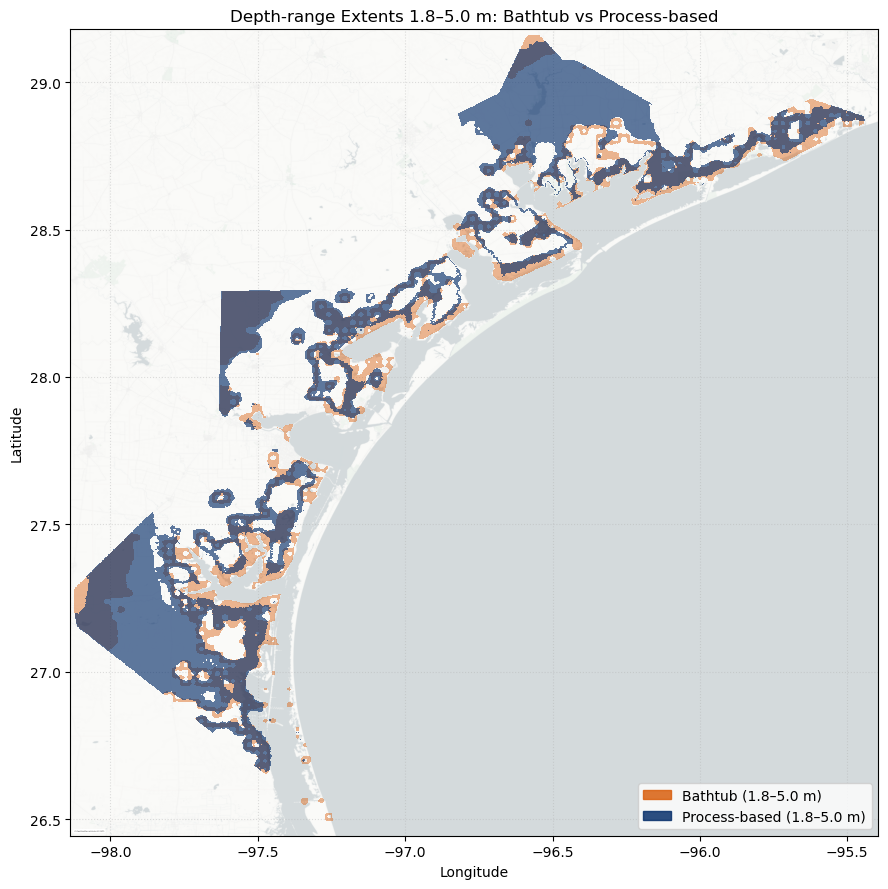

In [2]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import contextily as ctx
import math
import matplotlib.patches as mpatches

# ======== USER INPUTS ========
r_bath   = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_proc   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

DEPTH_RANGE = (1.8, 5.0)        # meters, inclusive range to map
TARGET_CRS  = "EPSG:4326"       # plot grid in lon/lat
TARGET_RES  = 0.0005            # ~45–55 m in TX; increase if memory is an issue
ADD_BASEMAP = True
ZOOM_MAIN   = 12
# =============================

def mask_in_range(path, vmin, vmax):
    """Return a 0/1 mask where vmin<=depth<=vmax, and a minimal profile."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        valid = (~arr.mask) & np.isfinite(arr)
        m = np.zeros(arr.shape, dtype="uint8")
        m[valid & (arr >= vmin) & (arr <= vmax)] = 1
        prof = {"crs": src.crs, "transform": src.transform,
                "width": src.width, "height": src.height}
    return m, prof

def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res):
    width  = int(math.ceil((right  - left) / res))
    height = int(math.ceil((top    - bottom) / res))
    transform = from_origin(left, top, res, res)
    return transform, width, height

def reproj_mask_uint8(src_mask, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask,
        destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform,      dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
    return dst

# 1) Build masks in range for both rasters
m_bath, p_bath = mask_in_range(r_bath, *DEPTH_RANGE)
m_proc, p_proc = mask_in_range(r_proc, *DEPTH_RANGE)

# 2) Common plotting grid in EPSG:4326
left, bottom, right, top = union_bounds_in_target([p_bath, p_proc], TARGET_CRS)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES)

# 3) Reproject masks to the common grid
dst_bath = reproj_mask_uint8(m_bath, p_bath, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_proc = reproj_mask_uint8(m_proc, p_proc, dst_transform, TARGET_CRS, dst_w, dst_h)

# 4) Plot
fig, ax = plt.subplots(figsize=(10, 9))
extent = (left, right, bottom, top)

# Transparent colormaps (0=fully transparent, 1=colored)
cmap_bath = ListedColormap([(0,0,0,0), (217/255, 95/255, 14/255, 0.45)])    # orange
cmap_proc = ListedColormap([(0,0,0,0), (  8/255, 48/255,107/255, 0.65)])    # dark blue

# Draw in order so overlap is visible
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bath, interpolation="nearest", zorder=3)
ax.imshow(dst_proc, extent=extent, origin="upper", cmap=cmap_proc, interpolation="nearest", zorder=4)

# Basemap
if ADD_BASEMAP:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                    zoom=ZOOM_MAIN, zorder=1, attribution_size=0)

# Labels / legend / cosmetics
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Depth-range Extents {DEPTH_RANGE[0]:.1f}–{DEPTH_RANGE[1]:.1f} m: "
             f"Bathtub vs Process-based")

legend_patches = [
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.85), label="Bathtub (1.8–5.0 m)"),
    mpatches.Patch(color=(  8/255, 48/255,107/255, 0.85), label="Process-based (1.8–5.0 m)"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


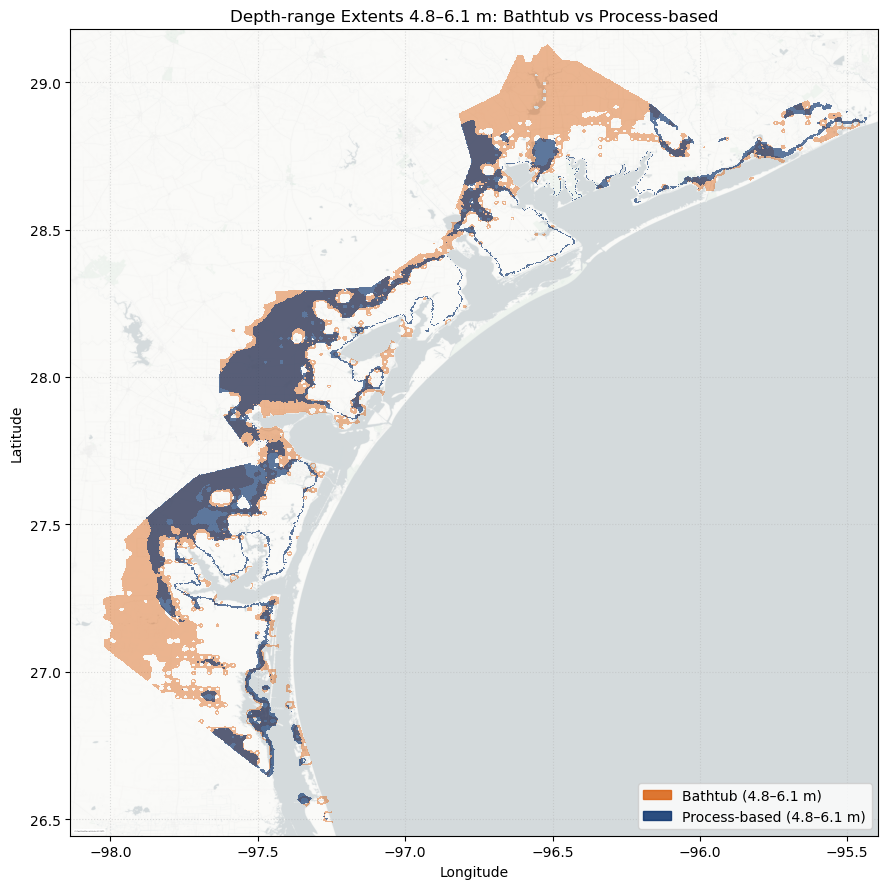

In [3]:
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import contextily as ctx
import math
import matplotlib.patches as mpatches

# ======== USER INPUTS ========
r_bath   = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
r_proc   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"

DEPTH_RANGE = (4.8, 6.1)        # meters, inclusive range to map
TARGET_CRS  = "EPSG:4326"       # plot grid in lon/lat
TARGET_RES  = 0.0005            # ~45–55 m in TX; increase if memory is an issue
ADD_BASEMAP = True
ZOOM_MAIN   = 12
# =============================

def mask_in_range(path, vmin, vmax):
    """Return a 0/1 mask where vmin<=depth<=vmax, and a minimal profile."""
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        valid = (~arr.mask) & np.isfinite(arr)
        m = np.zeros(arr.shape, dtype="uint8")
        m[valid & (arr >= vmin) & (arr <= vmax)] = 1
        prof = {"crs": src.crs, "transform": src.transform,
                "width": src.width, "height": src.height}
    return m, prof

def union_bounds_in_target(profiles, target_crs):
    xs_min, ys_min, xs_max, ys_max = [], [], [], []
    for p in profiles:
        h, w = p["height"], p["width"]
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, p["transform"])
        l, b, r, t = transform_bounds(p["crs"], target_crs, left, bottom, right, top, densify_pts=21)
        xs_min.append(l); ys_min.append(b); xs_max.append(r); ys_max.append(t)
    return min(xs_min), min(ys_min), max(xs_max), max(ys_max)

def make_dst_geo(left, bottom, right, top, res):
    width  = int(math.ceil((right  - left) / res))
    height = int(math.ceil((top    - bottom) / res))
    transform = from_origin(left, top, res, res)
    return transform, width, height

def reproj_mask_uint8(src_mask, src_prof, dst_transform, dst_crs, dst_w, dst_h):
    dst = np.zeros((dst_h, dst_w), dtype="uint8")
    reproject(
        source=src_mask,
        destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform,      dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
    return dst

# 1) Build masks in range for both rasters
m_bath, p_bath = mask_in_range(r_bath, *DEPTH_RANGE)
m_proc, p_proc = mask_in_range(r_proc, *DEPTH_RANGE)

# 2) Common plotting grid in EPSG:4326
left, bottom, right, top = union_bounds_in_target([p_bath, p_proc], TARGET_CRS)
dst_transform, dst_w, dst_h = make_dst_geo(left, bottom, right, top, TARGET_RES)

# 3) Reproject masks to the common grid
dst_bath = reproj_mask_uint8(m_bath, p_bath, dst_transform, TARGET_CRS, dst_w, dst_h)
dst_proc = reproj_mask_uint8(m_proc, p_proc, dst_transform, TARGET_CRS, dst_w, dst_h)

# 4) Plot
fig, ax = plt.subplots(figsize=(10, 9))
extent = (left, right, bottom, top)

# Transparent colormaps (0=fully transparent, 1=colored)
cmap_bath = ListedColormap([(0,0,0,0), (217/255, 95/255, 14/255, 0.45)])    # orange
cmap_proc = ListedColormap([(0,0,0,0), (  8/255, 48/255,107/255, 0.65)])    # dark blue

# Draw in order so overlap is visible
ax.imshow(dst_bath, extent=extent, origin="upper", cmap=cmap_bath, interpolation="nearest", zorder=3)
ax.imshow(dst_proc, extent=extent, origin="upper", cmap=cmap_proc, interpolation="nearest", zorder=4)

# Basemap
if ADD_BASEMAP:
    ctx.add_basemap(ax, crs=TARGET_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                    zoom=ZOOM_MAIN, zorder=1, attribution_size=0)

# Labels / legend / cosmetics
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Depth-range Extents {DEPTH_RANGE[0]:.1f}–{DEPTH_RANGE[1]:.1f} m: "
             f"Bathtub vs Process-based")

legend_patches = [
    mpatches.Patch(color=(217/255, 95/255, 14/255, 0.85), label="Bathtub (4.8–6.1 m)"),
    mpatches.Patch(color=(  8/255, 48/255,107/255, 0.85), label="Process-based (4.8–6.1 m)"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=True)

ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()
